In [2]:
!pip install openpyxl arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 50.5 MB/s eta 0:00:00


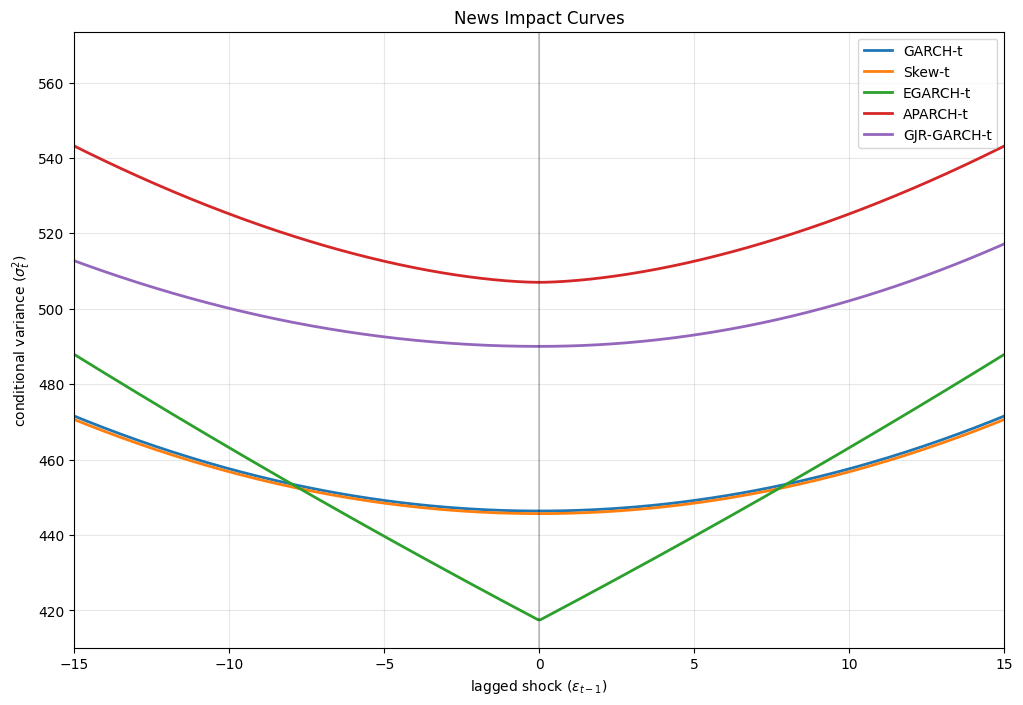

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Setup grafico
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True
warnings.filterwarnings('ignore')

def main():
    # --- 1. Definizione dei parametri forniti (Tabella) ---
    # Nota: la varianza di lungo periodo (sigma2) è usata come base per lo shock precedente
    models_params = {
        'GARCH-t':     {'omega': 50.1605, 'alpha': 0.1119, 'beta': 0.7883, 'gamma': 0, 'delta': 2},
        'Skew-t':      {'omega': 50.0267, 'alpha': 0.1109, 'beta': 0.7893, 'gamma': 0, 'delta': 2},
        'EGARCH-t':    {'omega': 0.6102,  'alpha': 0.2334, 'beta': 0.9019, 'gamma': 0, 'delta': 2},
        'APARCH-t':    {'omega': 19.0549, 'alpha': 0.1195, 'beta': 0.7946, 'gamma': 0, 'delta': 1.6937},
        'GJR-GARCH-t': {'omega': 49.5487, 'alpha': 0.1208, 'beta': 0.7903, 'gamma': -0.0199, 'delta': 2}
    }

    # Range di shock (epsilon_{t-1}) da -20 a +20 per vedere bene le code
    shocks = np.linspace(-20, 20, 500)

    plt.figure()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, (name, p) in enumerate(models_params.items()):
        # Calcolo varianza incondizionata per inizializzare la curva (sigma^2_{t-1})
        # Approssimazione: sigma2 = omega / (1 - alpha - beta) per i modelli standard
        if name == 'EGARCH-t':
            v_long = np.exp(p['omega'] / (1 - p['beta']))
        elif name == 'APARCH-t':
            # Per APARCH sigma^delta
            v_long = (p['omega'] / (1 - p['alpha'] - p['beta']))**(2/p['delta'])
        else:
            v_long = p['omega'] / (1 - p['alpha'] - p['beta'])

        # Calcolo della News Impact Curve (NIC)
        if name in ['GARCH-t', 'Skew-t']:
            # h_t = omega + alpha * e^2 + beta * sigma^2
            variances = p['omega'] + p['alpha'] * shocks**2 + p['beta'] * v_long

        elif name == 'GJR-GARCH-t':
            # h_t = omega + (alpha + gamma * I) * e^2 + beta * sigma^2
            variances = np.array([
                p['omega'] + (p['alpha'] + p['gamma'] * (s < 0)) * s**2 + p['beta'] * v_long
                for s in shocks
            ])

        elif name == 'EGARCH-t':
            # ln(h_t) = omega + alpha * (|z| - E|z|) + gamma * z + beta * ln(h_t-1)
            ez = np.sqrt(2/np.pi)
            z = shocks / np.sqrt(v_long)
            log_h = p['omega'] + p['alpha'] * (np.abs(z) - ez) + p['beta'] * np.log(v_long)
            variances = np.exp(log_h)

        elif name == 'APARCH-t':
            # h_t^(delta/2) = omega + alpha * (|e| - gamma*e)^delta + beta * h_{t-1}^(delta/2)
            # Nota: nel tuo output gamma non è presente per APARCH, assumiamo 0
            pow_h = p['omega'] + p['alpha'] * (np.abs(shocks))**p['delta'] + p['beta'] * (v_long**(p['delta']/2))
            variances = pow_h**(2/p['delta'])

        plt.plot(shocks, variances, label=name, color=colors[i], linewidth=2)

    # Formattazione
    plt.title('News Impact Curves')
    plt.xlabel('lagged shock ($\epsilon_{t-1}$)')
    plt.ylabel('conditional variance ($\sigma_t^2$)')
    plt.axvline(0, color='black', linestyle='-', alpha=0.2)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Inseriamo un focus sulla zona centrale
    plt.xlim(-15, 15)

    plt.show()

if __name__ == "__main__":
    main()